# Lab 04 – 4.1.4 (Bài tập về nhà): Tìm tập phổ biến bằng thư viện **apyori**
**Họ tên sinh viên: _(điền tên)_**

**Yêu cầu:** Tìm hiểu thư viện `apyori` (https://pypi.org/project/apyori) để tìm **tập phổ biến
(frequent itemsets)** từ dữ liệu giao dịch mua hàng tại siêu thị.
Tham khảo: https://www.kaggle.com/code/rockystats/apriori-algorithm-or-market-basket-analysis

**Dữ liệu:** `Market_Basket_Optimisation.csv` – 7.501 giao dịch của một siêu thị, mỗi dòng là một
hóa đơn liệt kê các sản phẩm đã mua (không có tiêu đề cột).

In [1]:
# --- 1. CÀI ĐẶT & NẠP THƯ VIỆN ---
# Cài apyori nếu chưa có:  pip install apyori
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from apyori import apriori

In [2]:
# --- 2. NẠP DỮ LIỆU ---
# File CSV không có dòng tiêu đề (header=None) vì mỗi giao dịch có số sản phẩm khác nhau.
df = pd.read_csv("Market_Basket_Optimisation.csv", header=None)
print("Kích thước bảng thô (giao dịch x số cột tối đa):", df.shape)
df.head()

Kích thước bảng thô (giao dịch x số cột tối đa): (7501, 20)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# --- 3. TIỀN XỬ LÝ: chuyển mỗi hóa đơn thành một danh sách sản phẩm ---
# apyori yêu cầu dữ liệu ở dạng "list các giao dịch", mỗi giao dịch là "list các sản phẩm".
# Ta duyệt từng dòng, loại bỏ các ô trống (NaN).
transactions = []
for i in range(len(df)):
    items = [str(x) for x in df.iloc[i].tolist() if pd.notna(x)]
    transactions.append(items)

print("Tổng số giao dịch:", len(transactions))
print("Ví dụ 3 giao dịch đầu:")
for t in transactions[:3]:
    print("  -", t)

Tổng số giao dịch: 7501
Ví dụ 3 giao dịch đầu:
  - ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
  - ['burgers', 'meatballs', 'eggs']
  - ['chutney']


In [4]:
# --- 4. KHẢO SÁT DỮ LIỆU (EDA) ---
# Thống kê toàn bộ sản phẩm xuất hiện
all_items = [item for tran in transactions for item in tran]
item_counts = Counter(all_items)
print("Số sản phẩm KHÁC NHAU trong siêu thị:", len(item_counts))
print("Tổng số lượt sản phẩm được mua:", len(all_items))

sizes = [len(t) for t in transactions]
print(f"Kích thước giỏ hàng: nhỏ nhất={min(sizes)}, lớn nhất={max(sizes)}, "
      f"trung bình={np.mean(sizes):.2f} sản phẩm/hóa đơn")

Số sản phẩm KHÁC NHAU trong siêu thị: 120
Tổng số lượt sản phẩm được mua: 29363
Kích thước giỏ hàng: nhỏ nhất=1, lớn nhất=20, trung bình=3.91 sản phẩm/hóa đơn


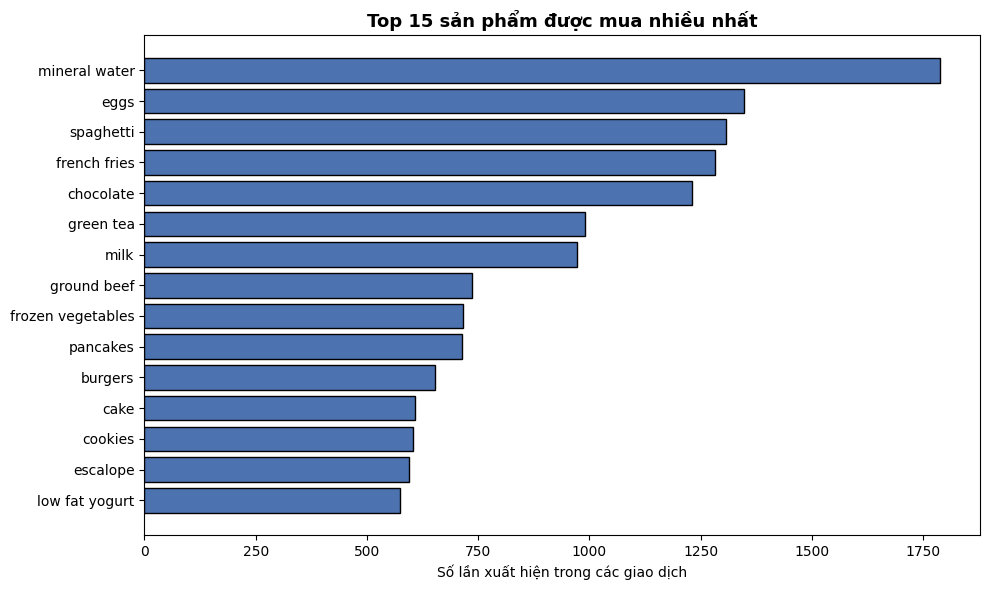

In [5]:
# --- 5. TOP 15 SẢN PHẨM BÁN CHẠY NHẤT ---
top15 = item_counts.most_common(15)
names = [x[0] for x in top15]
freqs = [x[1] for x in top15]

plt.figure(figsize=(10, 6))
plt.barh(names[::-1], freqs[::-1], color="#4C72B0", edgecolor="black")
plt.title("Top 15 sản phẩm được mua nhiều nhất", fontsize=13, fontweight="bold")
plt.xlabel("Số lần xuất hiện trong các giao dịch")
plt.tight_layout()
plt.show()

**Nhận xét:** Siêu thị có 120 mặt hàng khác nhau, trung bình mỗi hóa đơn có khoảng 3–4 sản phẩm.
`mineral water` (nước khoáng) là mặt hàng bán chạy nhất, theo sau là `eggs`, `spaghetti`,
`french fries`, `chocolate`... Đây là những "ứng viên" hàng đầu để tạo ra các tập phổ biến.

In [6]:
# --- 6. ÔN LẠI KHÁI NIỆM: tính SUPPORT / CONFIDENCE / LIFT bằng tay cho một ví dụ ---
# Xét luật {spaghetti} -> {mineral water}
N = len(transactions)
f_x = sum("spaghetti" in t for t in transactions)          # tần suất spaghetti
f_y = sum("mineral water" in t for t in transactions)      # tần suất mineral water
f_xy = sum(("spaghetti" in t and "mineral water" in t) for t in transactions)

support = f_xy / N
confidence = support / (f_x / N)
lift = confidence / (f_y / N)
print(f"Support({{spaghetti, mineral water}}) = {support:.4f}")
print(f"Confidence(spaghetti -> mineral water) = {confidence:.4f}")
print(f"Lift(spaghetti -> mineral water)       = {lift:.4f}")

Support({spaghetti, mineral water}) = 0.0597
Confidence(spaghetti -> mineral water) = 0.3430
Lift(spaghetti -> mineral water)       = 1.4391


- **Support** = tỷ lệ giao dịch chứa cả hai sản phẩm (mức độ phổ biến của tập).
- **Confidence** = xác suất mua mineral water khi đã mua spaghetti.
- **Lift > 1** nghĩa là hai sản phẩm có xu hướng được mua **cùng nhau** cao hơn ngẫu nhiên.

In [7]:
# --- 7. TÌM TẬP PHỔ BIẾN BẰNG apyori ---
# apyori.apriori() trả về một generator các "RelationRecord". Mỗi record chứa:
#   .items   -> tập sản phẩm (chính là tập phổ biến)
#   .support -> độ hỗ trợ của tập đó
# Vì bài này chỉ quan tâm TẬP PHỔ BIẾN nên đặt min_confidence=0, min_lift=0
# để lấy TẤT CẢ tập thỏa min_support (không lọc theo luật).
MIN_SUPPORT = 0.01   # sản phẩm/tập xuất hiện trong ít nhất 1% số giao dịch (~75 hóa đơn)

results = list(apriori(
    transactions,
    min_support=MIN_SUPPORT,
    min_confidence=0.0,
    min_lift=0.0,
    min_length=1
))
print(f"Số tập phổ biến tìm được (min_support={MIN_SUPPORT}):", len(results))

Số tập phổ biến tìm được (min_support=0.01): 257


In [8]:
# --- 8. ĐƯA KẾT QUẢ VỀ DataFrame CHO DỄ ĐỌC ---
rows = []
for r in results:
    rows.append({
        "itemset": ", ".join(sorted(r.items)),
        "length": len(r.items),
        "support": round(r.support, 4),
    })
freq_df = pd.DataFrame(rows).sort_values("support", ascending=False).reset_index(drop=True)

print("Số tập phổ biến theo độ dài:")
print(freq_df["length"].value_counts().sort_index())
print("\n--- 10 TẬP PHỔ BIẾN CÓ SUPPORT CAO NHẤT ---")
print(freq_df.head(10).to_string(index=False))

Số tập phổ biến theo độ dài:
length
1     75
2    165
3     17
Name: count, dtype: int64

--- 10 TẬP PHỔ BIẾN CÓ SUPPORT CAO NHẤT ---
          itemset  length  support
    mineral water       1   0.2384
             eggs       1   0.1797
        spaghetti       1   0.1741
     french fries       1   0.1709
        chocolate       1   0.1638
        green tea       1   0.1321
             milk       1   0.1296
      ground beef       1   0.0983
frozen vegetables       1   0.0953
         pancakes       1   0.0951


In [9]:
# --- 9. XEM RIÊNG TỪNG NHÓM ĐỘ DÀI ---
print("=== Tập phổ biến độ dài 1 (sản phẩm đơn) – top 8 ===")
print(freq_df[freq_df["length"] == 1].head(8).to_string(index=False))

print("\n=== Tập phổ biến độ dài 2 (cặp sản phẩm) – top 8 ===")
print(freq_df[freq_df["length"] == 2].head(8).to_string(index=False))

print("\n=== Tập phổ biến độ dài 3 (bộ ba sản phẩm) – top 8 ===")
print(freq_df[freq_df["length"] == 3].head(8).to_string(index=False))

=== Tập phổ biến độ dài 1 (sản phẩm đơn) – top 8 ===
      itemset  length  support
mineral water       1   0.2384
         eggs       1   0.1797
    spaghetti       1   0.1741
 french fries       1   0.1709
    chocolate       1   0.1638
    green tea       1   0.1321
         milk       1   0.1296
  ground beef       1   0.0983

=== Tập phổ biến độ dài 2 (cặp sản phẩm) – top 8 ===
                   itemset  length  support
  mineral water, spaghetti       2   0.0597
  chocolate, mineral water       2   0.0527
       eggs, mineral water       2   0.0509
       milk, mineral water       2   0.0480
ground beef, mineral water       2   0.0409
      chocolate, spaghetti       2   0.0392
    ground beef, spaghetti       2   0.0392
           eggs, spaghetti       2   0.0365

=== Tập phổ biến độ dài 3 (bộ ba sản phẩm) – top 8 ===
                                    itemset  length  support
      ground beef, mineral water, spaghetti       3   0.0171
        chocolate, mineral water, spaghe

**Diễn giải:** Cặp sản phẩm phổ biến nhất là **{mineral water, spaghetti}**, tiếp đến là
**{chocolate, mineral water}**, **{eggs, mineral water}**... Có thể thấy `mineral water` xuất
hiện trong hầu hết các tập phổ biến – nó là "trung tâm" của hành vi mua sắm. Bộ ba nổi bật nhất
là **{ground beef, mineral water, spaghetti}** – gợi ý một bữa ăn tối điển hình.

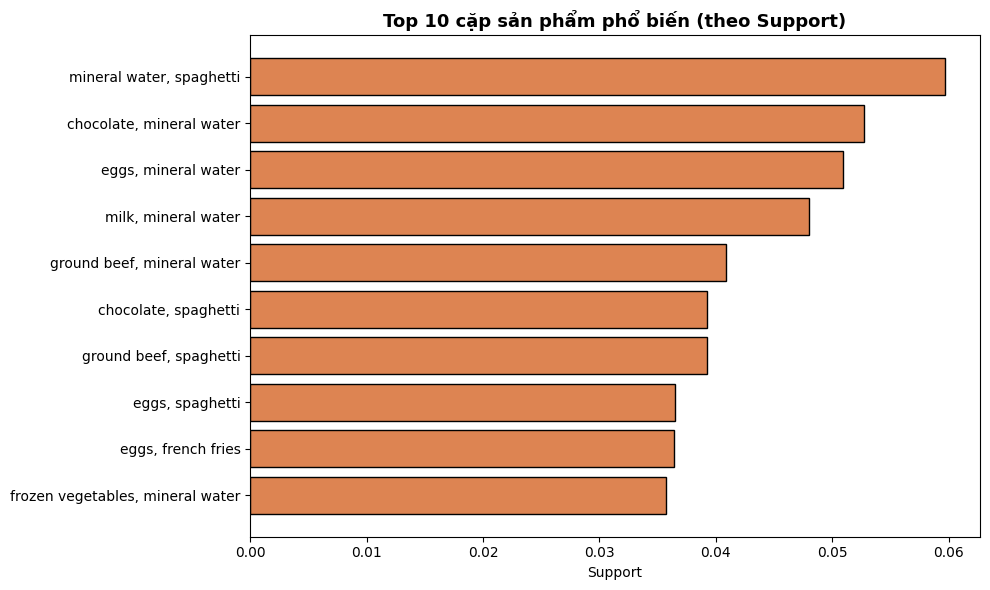

In [10]:
# --- 10. TRỰC QUAN HÓA TOP CẶP SẢN PHẨM PHỔ BIẾN ---
pairs = freq_df[freq_df["length"] == 2].head(10)
plt.figure(figsize=(10, 6))
plt.barh(pairs["itemset"][::-1], pairs["support"][::-1],
         color="#DD8452", edgecolor="black")
plt.title("Top 10 cặp sản phẩm phổ biến (theo Support)", fontsize=13, fontweight="bold")
plt.xlabel("Support")
plt.tight_layout()
plt.show()

In [11]:
# --- 11. ẢNH HƯỞNG CỦA NGƯỠNG min_support ---
# Ngưỡng support càng thấp -> càng nhiều tập phổ biến (và tập càng dài) được tìm thấy.
print(f"{'min_support':>12} | {'Tổng số tập':>12} | Phân bố theo độ dài")
print("-" * 60)
for ms in [0.05, 0.02, 0.01, 0.005, 0.003]:
    res = list(apriori(transactions, min_support=ms,
                       min_confidence=0.0, min_lift=0.0, min_length=1))
    dist = dict(sorted(Counter(len(r.items) for r in res).items()))
    print(f"{ms:>12} | {len(res):>12} | {dist}")

 min_support |  Tổng số tập | Phân bố theo độ dài
------------------------------------------------------------
        0.05 |           28 | {1: 25, 2: 3}
        0.02 |          103 | {1: 53, 2: 50}
        0.01 |          257 | {1: 75, 2: 165, 3: 17}


       0.005 |          725 | {1: 101, 2: 451, 3: 173}


       0.003 |         1443 | {1: 115, 2: 786, 3: 504, 4: 38}


## Kết luận

1. **Thư viện `apyori`** giúp tìm tập phổ biến rất gọn: chỉ cần đưa dữ liệu về dạng *list các
   giao dịch* rồi gọi `apriori(transactions, min_support=...)`. Mỗi kết quả trả về gồm tập sản
   phẩm (`.items`) và độ hỗ trợ (`.support`).
2. **Tiền xử lý** là bước quan trọng: chuyển bảng CSV thô (mỗi dòng nhiều ô, có NaN) thành danh
   sách các giao dịch sạch.
3. **Kết quả:** với `min_support = 0.01`, `mineral water` là sản phẩm phổ biến nhất; cặp
   {mineral water, spaghetti} và bộ ba {ground beef, mineral water, spaghetti} là các tập phổ
   biến tiêu biểu — thông tin hữu ích để siêu thị sắp xếp quầy hàng và làm khuyến mãi combo.
4. **Ngưỡng `min_support`** điều khiển độ "khắt khe": hạ ngưỡng thì số tập phổ biến tăng nhanh
   và xuất hiện các tập dài hơn, nhưng nhiều tập trong đó có thể ít ý nghĩa thực tế.

*Gợi ý mở rộng (mục 4.2.4): từ các tập phổ biến này, `apyori` còn cho phép trích **luật kết hợp**
qua thuộc tính `.ordered_statistics` (kèm confidence và lift) để đưa ra khuyến nghị "mua A → gợi ý B".*